# Exploring The Guardian's University League Tables
The following code explore the overall ranking and the individual subject-level rankings using data visualizations, correlation metrics, and basic statistical analysis.

## Load Tables
The following code loads the overall table as well as individual tables for each subject area.

In [2]:
from extract_data import load_data

ranking = load_data()

main_rank = ranking["main_rank"]
subjects = ranking["subjects"]
subject_dataframes = ranking["subject_dataframes"]

In [37]:
# Preview main table
main_rank.head(10)

,institutionId,name,url,rank2026,rank2025,rank2024,guardianScore,percentSatisfiedWithTeaching,expenditurePerStudent,studentStaffRatio,careerProspects,valueAdded,averageEntryTariff,percentSatisfiedWithAssessment,continuation
0,0156,Oxford,https://www.theguardian.com/education/2009/may...,1,1.0,2.0,100,94,10,9.1,92,6.3,197,76,97.3
1,0173,St Andrews,https://www.theguardian.com/education/2009/may...,2,2.0,1.0,98.4,92.8,6.5,11,90,5.5,210,81.7,96.8
2,0114,Cambridge,https://www.theguardian.com/education/2009/may...,3,3.0,3.0,94.6,93.4,9.4,10.8,92,5.9,210,72.9,98.4
3,0137,London School of Economics,https://www.theguardian.com/education/2009/may...,4,4.0,4.0,93.8,89.4,8.7,11.4,93,5.9,185,76.2,96.4
4,0116,Durham,https://www.theguardian.com/education/2009/may...,5,6.0,7.0,85.5,90.5,6.4,12.4,89,6,180,81.6,96.7
5,0132,Imperial College,https://www.theguardian.com/education/2009/may...,6,5.0,5.0,82.9,87.7,8.7,11.7,95,6.1,196,67.3,94.9
6,0163,Warwick,https://www.theguardian.com/education/2009/may...,7,8.0,9.0,79.1,90,7.7,11.7,89,5.1,171,77.8,95.3
7,0109,Bath,https://www.theguardian.com/education/2009/may...,8,7.0,6.0,76.1,88.1,5.9,15.1,90,6.2,171,75.2,96.6
8,0024,University of the Arts London,https://www.theguardian.com/education/2009/may...,9,13.0,15.0,73.9,83.1,9.6,9.9,71,6.5,141,84.4,91
9,0149,UCL,https://www.theguardian.com/education/2009/may...,10,9.0,8.0,73.5,86.9,6.1,10.7,89,6,172,75.3,95.9


In [43]:
subjects

[{'id': 'S250', 'title': 'Accounting and finance'},
 {'id': 'S195', 'title': 'Aerospace engineering'},
 {'id': 'S040', 'title': 'Anatomy and physiology'},
 {'id': 'S150', 'title': 'Animal science and agriculture'},
 {'id': 'S225', 'title': 'Animation and game design'},
 {'id': 'S325', 'title': 'Anthropology and archaeology'},
 {'id': 'S450', 'title': 'Architecture'},
 {'id': 'S100', 'title': 'Biology'},
 {'id': 'S045', 'title': 'Biomedical science'},
 {'id': 'S240', 'title': 'Business and management'},
 {'id': 'S170', 'title': 'Chemical engineering'},
 {'id': 'S110', 'title': 'Chemistry'},
 {'id': 'S053', 'title': "Children's nursing"},
 {'id': 'S200', 'title': 'Civil engineering'},
 {'id': 'S460', 'title': 'Classics and ancient history'},
 {'id': 'S220', 'title': 'Computer science and information systems'},
 {'id': 'S500', 'title': 'Construction, surveying and planning'},
 {'id': 'S385', 'title': 'Creative writing'},
 {'id': 'S315', 'title': 'Criminology'},
 {'id': 'S020', 'title': 'D

In [46]:
subject_dataframes['S102'].head(2)

,institutionId,name,url,courses,rank,guardianScore,percentSatisfiedWithTeaching,expenditurePerStudent,studentStaffRatio,careerProspects,valueAdded,averageEntryTariff,percentSatisfiedWithAssessment,continuation,subject_id,subject
0,0168,Glasgow,https://www.theguardian.com/education/2009/may...,[{'url': 'http://www.gla.ac.uk/undergraduate/d...,1,100,88.2,9.0,14.5,75.0,8.0,216,81.8,92.5,S102,Zoology
1,0112,Bristol,https://www.theguardian.com/education/2009/may...,[{'url': 'https://www.bristol.ac.uk/study/unde...,2,94.8,96.3,8.0,14.6,68.0,5.0,156,77,100,S102,Zoology


### Save files
To avoid having to reload ranking data, save to files.

In [5]:
from pathlib import Path
import pickle

data_dir = Path("data")
data_dir.mkdir(exist_ok=True, parents=True)

output_path = data_dir / "main_rank.csv"
main_rank.to_csv(output_path, index=False)

with open(data_dir / "data.pkl", "wb") as f:
    pickle.dump(subject_dataframes, f)

## Data Exploration
First select only subjects for which Anglia Ruskin is a provider.

In [ ]:
subject_dataframes_anglia = {
    subject_id: subject_df
    for subject_id, subject_df in subject_dataframes.items()
    if subject_df["name"].eq("Anglia Ruskin").any()
}

37

### Plot Correlations
Plot correlations between main score and each metric.

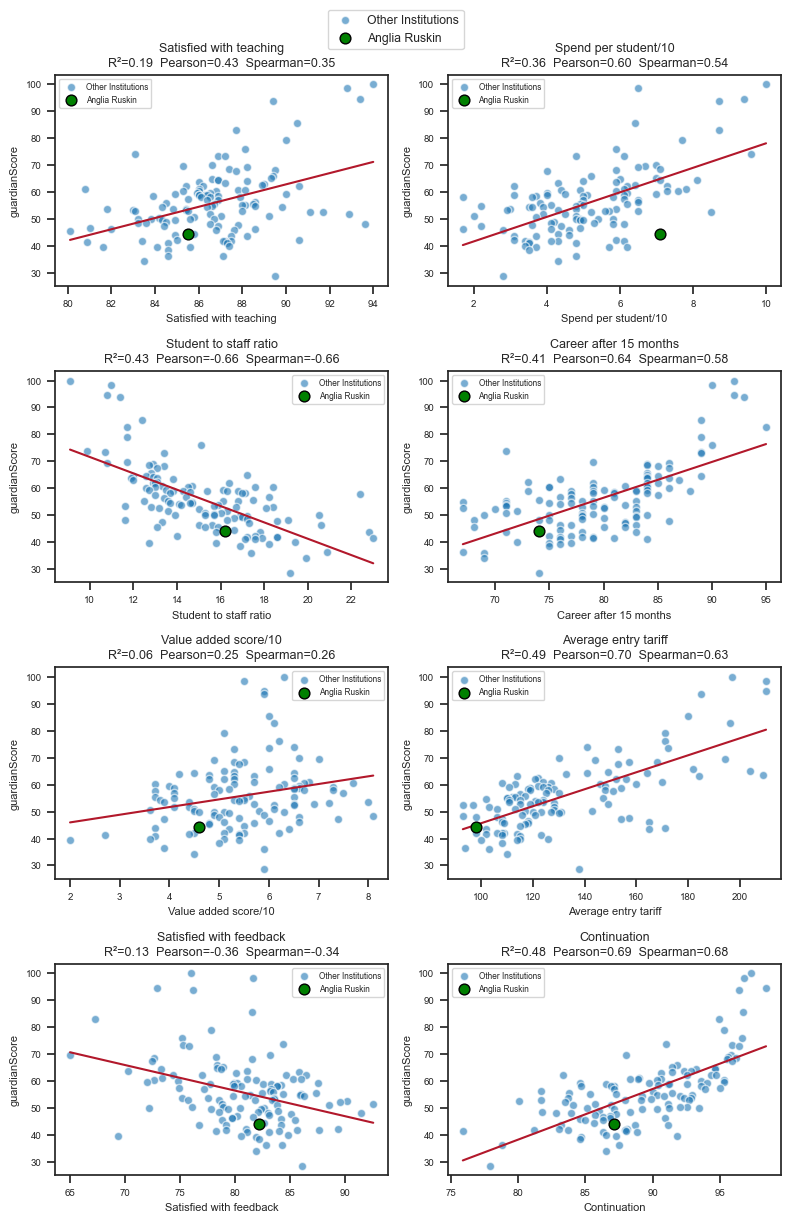

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
df = pd.read_csv("data/main_rank.csv")
TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

metrics = main_rank.columns[7:].to_list()

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):
    sub = df[[col, TARGET, "name"]].dropna()
    x, y = sub[col].values, sub[TARGET].values

    # Fit linear regression
    slope, intercept, r_pearson, p_val, se = stats.linregress(x, y)
    r2 = r_pearson ** 2
    r_spearman, _ = stats.spearmanr(x, y)

    # Split highlighted institution from the rest
    is_highlight = sub["name"] == HIGHLIGHT
    rest, hl = sub[~is_highlight], sub[is_highlight]

    # Scatter: rest in blue, highlight in green (on top, larger, outlined)
    ax.scatter(rest[col], rest[TARGET], alpha=0.6, edgecolor="white", s=35, color="tab:blue",
               label="Other Institutions")
    ax.scatter(hl[col], hl[TARGET], color="green", edgecolor="black",
               s=60, zorder=5, label=HIGHLIGHT)

    # Regression line
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="#b2182b", linewidth=1.5)

    # Annotate stats
    ax.set_title(
        f"{label}\nR²={r2:.2f}  Pearson={r_pearson:.2f}  Spearman={r_spearman:.2f}",
        fontsize=9
    )
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc="best")

# Single shared legend for the highlighted institution
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

C:\Users\md82\AppData\Local\Temp\ipykernel_22176\279504802.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(


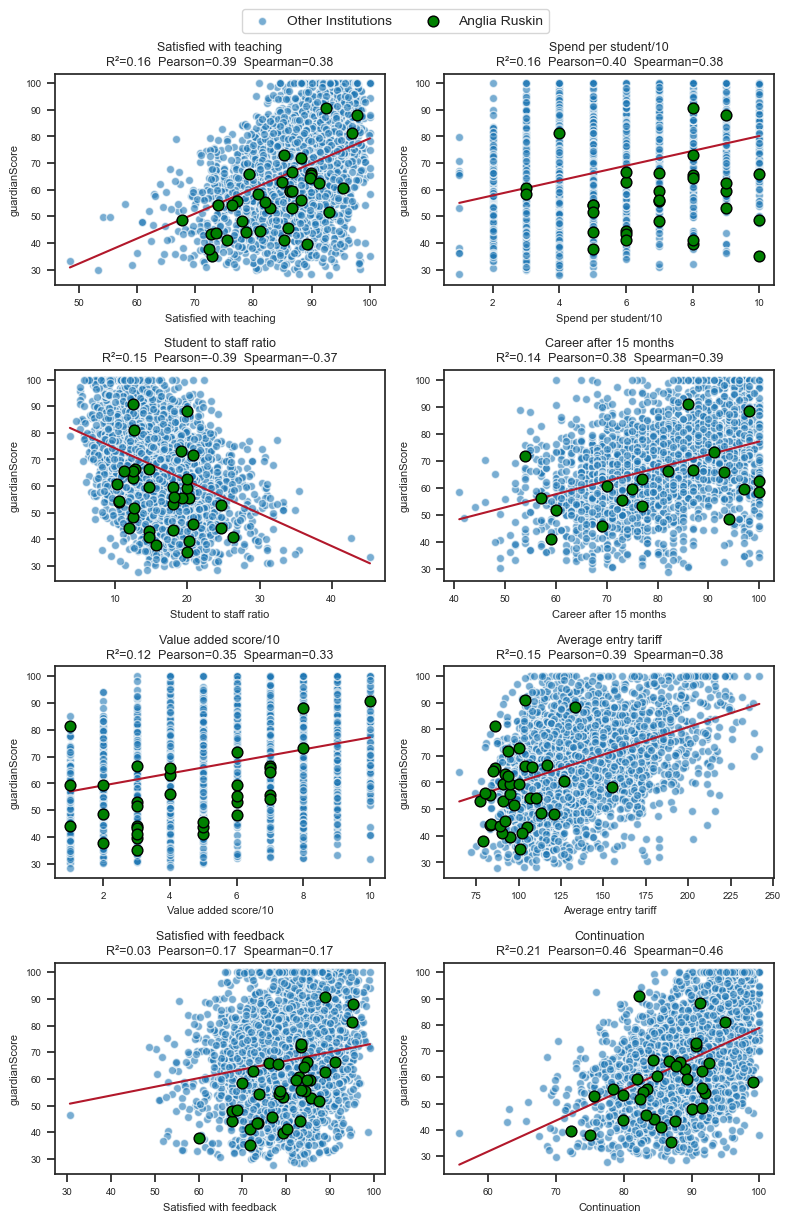

In [112]:
# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
dfs = subject_dataframes

TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

# assumes all dataframes share the same metric columns from index 7 onward
metrics = list(dfs.values())[0].columns[6:14].to_list()

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):

    # Concatenate this metric's data from every dataframe into one pooled sample
    combined = pd.concat(
        [df[[col, TARGET, "name"]].assign(source=df_key) for df_key, df in dfs.items()],
        ignore_index=True
    )
     
    # Force numeric dtypes — guards against stray strings/junk in the CSV
    combined[col] = pd.to_numeric(combined[col], errors="coerce")
    combined[TARGET] = pd.to_numeric(combined[TARGET], errors="coerce")
    combined = combined.dropna(subset=[col, TARGET])

    x, y = combined[col].values, combined[TARGET].values

    # Fit ONE regression line to the pooled data
    slope, intercept, r_pearson, p_val, se = stats.linregress(x, y)
    r2 = r_pearson ** 2
    r_spearman, _ = stats.spearmanr(x, y)

    # Split highlighted institution from the rest (still pooled across sources)
    is_highlight = combined["name"] == HIGHLIGHT
    rest, hl = combined[~is_highlight], combined[is_highlight]

    # Scatter: rest colored by source dataframe
    ax.scatter(rest[col], rest[TARGET], alpha=0.6, edgecolor="white", s=35,
               color="tab:blue", label="Other Institutions")

    # Highlighted institution always in green, on top
    ax.scatter(hl[col], hl[TARGET], color="green", edgecolor="black",
               s=60, zorder=5, label=HIGHLIGHT)

    # Regression line fit to ALL combined data
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="#b2182b", linewidth=1.5)

    # Annotate stats (computed on pooled data)
    ax.set_title(
        f"{label}\nR²={r2:.2f}  Pearson={r_pearson:.2f}  Spearman={r_spearman:.2f}",
        fontsize=9
    )
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)

# Single shared legend for the highlighted institution and each source dataframe
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.tight_layout()
plt.show()